# Limpieza y normalización del dataset

En esta actividad se realiza el preprocesamiento del corpus de voz seleccionado para garantizar la compatibilidad con los modelos de reconocimiento automático del habla Whisper y Vosk.

Las tareas incluyen:

- Verificación de la integridad de los archivos de audio.
- Eliminación de registros inválidos.
- Conversión de todos los audios al formato WAV.
- Conversión a audio mono.
- Estandarización de la frecuencia de muestreo a 16 kHz.
- Organización del dataset procesado.

Las transcripciones de referencia no forman parte de esta actividad y serán generadas posteriormente.

In [1]:
#Importe de librerías
from pathlib import Path
import os
import shutil
import librosa
from pydub import AudioSegment
from tqdm import tqdm

d:\User\Escritorio\tareas\Ciclo 8\ProyectoFinal\.venv\Lib\site-packages\pydub\utils.py:170: RuntimeWarning: Couldn't find ffmpeg or avconv - defaulting to ffmpeg, but may not work
  warn("Couldn't find ffmpeg or avconv - defaulting to ffmpeg, but may not work", RuntimeWarning)


In [11]:
#Rutas 
from pathlib import Path

ROOT = Path.cwd()

if ROOT.name == "notebooks":
    ROOT = ROOT.parent

DATA = ROOT / "data"

RAW = DATA / "raw"
EXTRACTED = DATA / "extracted/audios"
SAMPLE = DATA / "sample50"

PROCESSED = DATA / "processed"

METADATA = DATA / "metadata"

PROCESSED.mkdir(exist_ok=True)

In [12]:
#Busqueda de audios 
audio_files = sorted(EXTRACTED.glob("*"))

len(audio_files)

50

In [14]:
#Verificación de integridad de los audios
import librosa
import soundfile as sf
import pandas as pd
from pathlib import Path
from tqdm import tqdm

audio_info = []

for audio_path in tqdm(sorted(EXTRACTED.glob("*"))):

    try:
        audio, sr = librosa.load(audio_path, sr=None, mono=False)

        info = sf.info(audio_path)

        channels = info.channels
        duration = info.duration
        formato = audio_path.suffix.replace(".", "").upper()

        estado = "Válido"

    except Exception as e:

        sr = None
        channels = None
        duration = None
        formato = audio_path.suffix.replace(".", "").upper()
        estado = f"Inválido ({e})"

    audio_info.append({
        "archivo": audio_path.name,
        "formato": formato,
        "duracion_seg": duration,
        "sample_rate": sr,
        "canales": channels,
        "estado": estado
    })

df_integridad = pd.DataFrame(audio_info)

df_integridad.head()

  0%|          | 0/50 [00:00<?, ?it/s]d:\User\Escritorio\tareas\Ciclo 8\ProyectoFinal\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
100%|██████████| 50/50 [00:04<00:00, 10.58it/s]


,archivo,formato,duracion_seg,sample_rate,canales,estado
0,spontaneous-speech-es-71834.mp3,MP3,11.2755,32000,1,Válido
1,spontaneous-speech-es-71835.mp3,MP3,24.4875,32000,1,Válido
2,spontaneous-speech-es-74952.mp3,MP3,6.3795,32000,1,Válido
3,spontaneous-speech-es-74953.mp3,MP3,4.7955,32000,1,Válido
4,spontaneous-speech-es-74954.mp3,MP3,5.6595,32000,1,Válido


In [15]:
#Guardar el DataFrame en un archivo CSV
df_integridad.to_csv(
    METADATA / "reporte_integridad.csv",
    index=False,
    encoding="utf-8-sig"
)

In [16]:
#Eliminar los archivos de audio inválidos
invalid_files = df_integridad[df_integridad["estado"].str.startswith("Inválido")]["archivo"]

In [20]:
import librosa

audio, sr = librosa.load(
    "../data/extracted/audios/spontaneous-speech-es-71834.mp3",
    sr=16000,
    mono=True
)

print(audio.shape)
print(sr)

(180288,)
16000


In [23]:
#Normalización de los audios a 16kHz y 1 canal
import librosa
import soundfile as sf
from pathlib import Path
from tqdm import tqdm

PROCESSED.mkdir(parents=True, exist_ok=True)

for audio_path in tqdm(sorted(EXTRACTED.glob("*.mp3"))):

    try:
        # Cargar el audio, convertir a mono y remuestrear a 16 kHz
        audio, sr = librosa.load(
            audio_path,
            sr=16000,
            mono=True
        )

        output_path = PROCESSED / f"{audio_path.stem}.wav"

        # Guardar como WAV
        sf.write(output_path, audio, 16000)

    except Exception as e:
        print(f"Error con {audio_path.name}: {e}")

print("Conversión finalizada.")

100%|██████████| 50/50 [00:03<00:00, 15.63it/s]

Conversión finalizada.


In [25]:
#Generar dataset preprocesado
from pydub import AudioSegment

PROCESSED.mkdir(parents=True, exist_ok=True)

for audio_path in tqdm(sorted(PROCESSED.glob("*"))):

    try:

        audio = AudioSegment.from_file(audio_path)

        audio = audio.set_channels(1)
        audio = audio.set_frame_rate(16000)

        output_path = PROCESSED / (audio_path.stem + ".wav")

        audio.export(output_path, format="wav")

    except Exception as e:

        print(f"No se pudo procesar {audio_path.name}: {e}")

print("Preprocesamiento finalizado.")

100%|██████████| 50/50 [00:00<00:00, 71.82it/s]

Preprocesamiento finalizado.


In [26]:
#Generacion de metadata 
dataset_final = []

for audio_path in tqdm(sorted(PROCESSED.glob("*.wav"))):

    info = sf.info(audio_path)

    dataset_final.append({

        "archivo": audio_path.name,
        "duracion_seg": round(info.duration,2),
        "sample_rate": info.samplerate,
        "canales": info.channels,
        "formato": audio_path.suffix.replace(".","").upper()

    })

df_dataset = pd.DataFrame(dataset_final)

df_dataset.head()

100%|██████████| 50/50 [00:00<00:00, 60.37it/s]


,archivo,duracion_seg,sample_rate,canales,formato
0,spontaneous-speech-es-71834.wav,11.27,16000,1,WAV
1,spontaneous-speech-es-71835.wav,24.48,16000,1,WAV
2,spontaneous-speech-es-74952.wav,6.37,16000,1,WAV
3,spontaneous-speech-es-74953.wav,4.79,16000,1,WAV
4,spontaneous-speech-es-74954.wav,5.65,16000,1,WAV


In [27]:
#Guardad metadata
df_dataset.to_csv(
    METADATA/"dataset_procesado.csv",
    index=False,
    encoding="utf-8-sig"
)

In [29]:
#Estadísticas 
print("="*50)

print("RESUMEN DEL PREPROCESAMIENTO")

print("="*50)

print(f"Audios originales      : {len(list(EXTRACTED.glob('*')))}")

print(f"Audios procesados      : {len(df_dataset)}")

print(f"Duración promedio      : {df_dataset['duracion_seg'].mean():.2f} s")

print(f"Duración mínima        : {df_dataset['duracion_seg'].min():.2f} s")

print(f"Duración máxima        : {df_dataset['duracion_seg'].max():.2f} s")

print(f"Frecuencia muestreo    : {df_dataset['sample_rate'].unique()}")

print(f"Canales                : {df_dataset['canales'].unique()}")

print(f"Formato                : {df_dataset['formato'].unique()}")

print("="*50)

RESUMEN DEL PREPROCESAMIENTO
Audios originales      : 50
Audios procesados      : 50
Duración promedio      : 6.59 s
Duración mínima        : 1.48 s
Duración máxima        : 24.48 s
Frecuencia muestreo    : [16000]
Canales                : [1]
Formato                : <StringArray>
['WAV']
Length: 1, dtype: str


In [30]:
#Vistas 
FIGURES = ROOT/"reports"/"figures"

FIGURES.mkdir(parents=True, exist_ok=True)

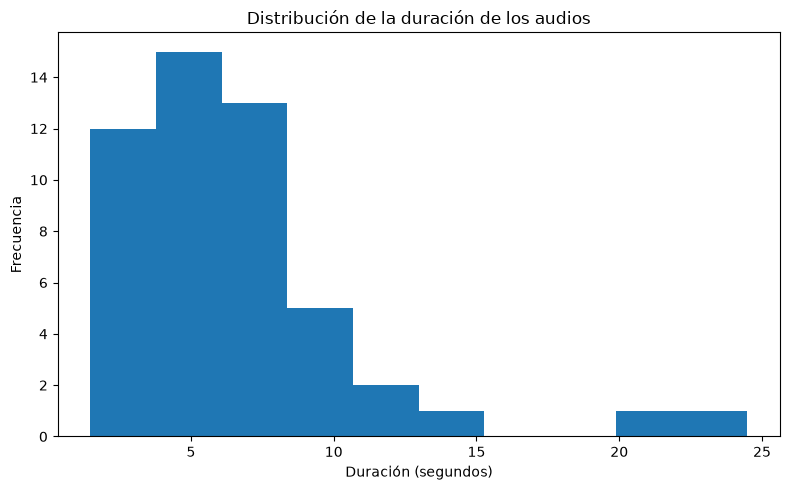

In [31]:
#Histograma de duración de los audios
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.hist(df_dataset["duracion_seg"], bins=10)

plt.title("Distribución de la duración de los audios")

plt.xlabel("Duración (segundos)")

plt.ylabel("Frecuencia")

plt.tight_layout()

plt.savefig(FIGURES/"histograma_duracion.png", dpi=300)

plt.show()

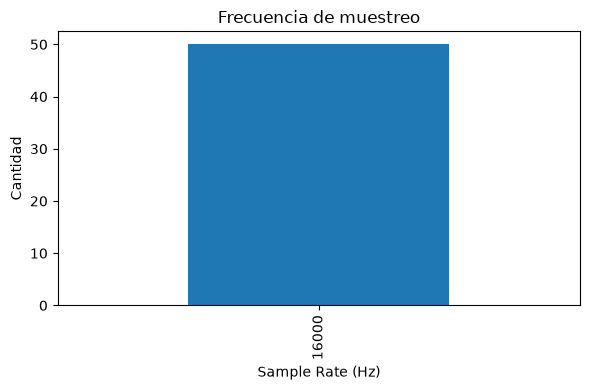

In [32]:
#Distribución Sample Rate
plt.figure(figsize=(6,4))

df_dataset["sample_rate"].value_counts().sort_index().plot(kind="bar")

plt.title("Frecuencia de muestreo")

plt.xlabel("Sample Rate (Hz)")

plt.ylabel("Cantidad")

plt.tight_layout()

plt.savefig(FIGURES/"sample_rate.png", dpi=300)

plt.show()

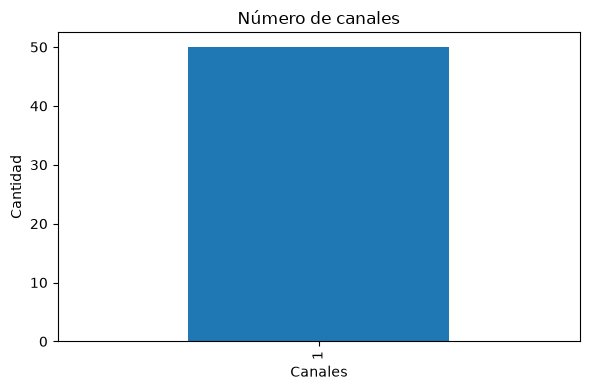

In [33]:
#Canales 
plt.figure(figsize=(6,4))

df_dataset["canales"].value_counts().sort_index().plot(kind="bar")

plt.title("Número de canales")

plt.xlabel("Canales")

plt.ylabel("Cantidad")

plt.tight_layout()

plt.savefig(FIGURES/"canales.png", dpi=300)

plt.show()

In [ ]:
#Reporte final 
estadisticas = pd.DataFrame({

    "Métrica":[

        "Audios originales",

        "Audios procesados",

        "Duración promedio",

        "Duración mínima",

        "Duración máxima",

        "Frecuencia de muestreo",

        "Canales"

    ],

    "Valor":[

        len(list(EXTRACTED.glob("*"))),

        len(df_dataset),

        round(df_dataset["duracion_seg"].mean(),2),

        round(df_dataset["duracion_seg"].min(),2),

        round(df_dataset["duracion_seg"].max(),2),

        ", ".join(map(str, df_dataset["sample_rate"].unique())),

        ", ".join(map(str, df_dataset["canales"].unique()))

    ]

})

estadisticas.to_csv(

    METADATA/"reporte_preprocesamiento.csv",

    index=False,

    encoding="utf-8-sig"

)

print("Reporte generado correctamente.")

Reporte generado correctamente.
